In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from tueplots import bundles
from scipy.stats import mannwhitneyu
from evaluation.main_ihdp import load_data as load_ihdp_data
from evaluation.main_CRC_censoring import load_data as load_crc_data

In [2]:
name_map = {'s-learner': 'S-Learner',
            't-learner': 'T-Learner',
            'tarnet': 'TarNet',
            'cfrnet': 'CFRNet',
            'sa-tedvae-m0': 'SA-TEDVAE-NIC',
            'sa-tedvae-m1': 'SA-TEDVAE-CP',
            'sa-tedvae-m2': 'SA-TEDVAE-CT',
            'tmle': 'TMLE'}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
})

Results for ihdp in setting _survival_a and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 10.05 / 9.61%
Proportion of p-values smaller than 0.05 = 4.68 / 5.02%
Proportion of p-values smaller than 0.01 = 0.73 / 0.89%
Results for ihdp in setting _survival_b and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 49.68 / 51.52%
Proportion of p-values smaller than 0.05 = 41.59 / 44.16%
Proportion of p-values smaller than 0.01 = 29.00 / 33.59%
Results for ihdp in setting _survival_c and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 43.32 / 53.52%
Proportion of p-values smaller than 0.05 = 35.00 / 46.61%
Proportion of p-values smaller than 0.01 = 21.91 / 35.02%


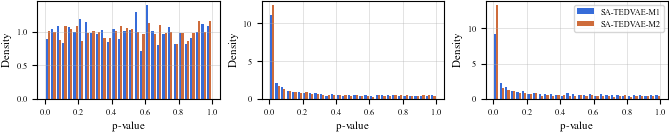

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\699589927.py:131: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


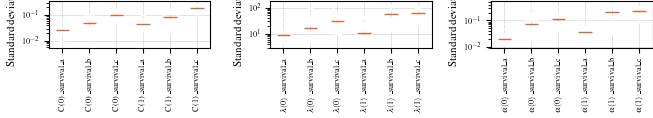

Results for crc in setting no_censor and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 10.36 / 24.57%
Proportion of p-values smaller than 0.05 = 4.86 / 17.25%
Proportion of p-values smaller than 0.01 = 1.07 / 8.75%
Results for crc in setting ic and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 29.86 / 18.71%
Proportion of p-values smaller than 0.05 = 21.57 / 12.11%
Proportion of p-values smaller than 0.01 = 12.14 / 4.50%


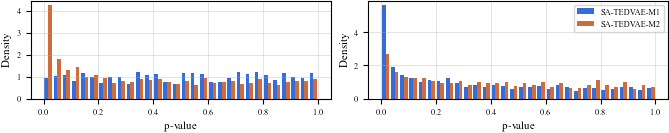

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\699589927.py:131: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


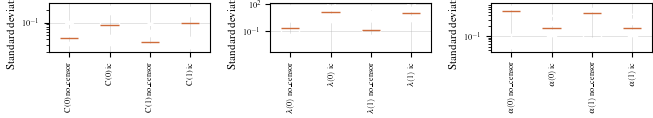

In [3]:
for case in ['ihdp', 'crc']:

    if case == 'ihdp':
        save_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'evaluation', 'results_IHDP')
        num_covars = 25
    elif case == 'crc':
        save_path = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'evaluation', 'results_CRC_censoring')
        num_covars = 12
    else:
        raise RuntimeError('Case not recognized ' + str(case))
    results_path = os.path.join(save_path, 'results')
    plots_path = os.path.join(save_path, 'plots')

    with open(os.path.join(results_path, 'results.pkl'), 'rb') as f:
        results = pickle.load(f)

    settings = [key for key in results.keys()]
    models = [key for key in results[settings[0]].keys()]
    n_datasets = len(results[settings[0]][models[0]]['ate_error_test'])

    p_vals_dict = {}
    std_dict = {setting: {'scale_0': [], 'scale_1': [], 'concentration_0': [], 'concentration_1': [], 'prop_0': [], 'prop_1': []} for setting in settings}

    for model_name in ['sa-tedvae-m1', 'sa-tedvae-m2']:
        p_vals_dict[model_name] = {}
        for setting in settings:
            p_vals_dict[model_name][setting] = []
            for i in range(n_datasets):
                if case == 'ihdp':
                    data = load_ihdp_data(i=i+1, setting=setting)
                else:
                    data = load_crc_data(i=i, setting=setting)

                if model_name == 'sa-tedvae-m1':
                    c_0 = results[setting][model_name]['c_test'][i][0]
                    c_1 = results[setting][model_name]['c_test'][i][1]
                    std_dict[setting]['prop_0'].append(np.std(c_0))
                    std_dict[setting]['prop_1'].append(np.std(c_1))
                    vals_to_test = (c_0, c_1)
                else:
                    scale_0 = results[setting][model_name]['censor_scale_test'][i][0]
                    concentration_0 = results[setting][model_name]['censor_concentration_test'][i][0]
                    scale_1 = results[setting][model_name]['censor_scale_test'][i][1]
                    concentration_1 = results[setting][model_name]['censor_concentration_test'][i][1]
                    std_dict[setting]['scale_0'].append(np.std(scale_0))
                    std_dict[setting]['scale_1'].append(np.std(scale_1))
                    std_dict[setting]['concentration_0'].append(np.std(concentration_0))
                    std_dict[setting]['concentration_1'].append(np.std(concentration_1))
                    vals_to_test = (scale_0, scale_1, concentration_0, concentration_1)
                # Now, split the data: for each covariate, keep those above and below the median, and run the mann whitney u test
                p_vals = []
                for covar in range(len(data['data_types'])):
                    dtype = data['data_types'][covar]
                    if (dtype == 'continuous') or ('categorical' in dtype):
                        covar_data = data['X_test'][:, covar]
                        median = np.median(covar_data)
                        idx_1 = np.where(covar_data <= median)[0]
                        idx_2 = np.where(covar_data > median)[0]
                    elif dtype == 'binary':
                        covar_data = data['X_test'][:, covar]
                        idx_1 = np.where(covar_data <= 0.5)[0] # Assume data is either 0 or 1
                        idx_2 = np.where(covar_data > 0.5)[0]
                    else:
                        raise ValueError("Unrecognized data type " + str(data['data_types'][covar]))
                    # Now, run the mann whitney u test for each parameter, if the data is not too unbalanced
                    n1, n2 = len(idx_1), len(idx_2)
                    if min(n1, n2) >= 20 and 0.5 < (n1 / n2) < 2.0:
                        for val in vals_to_test:
                            p_val = mannwhitneyu(val[idx_1], val[idx_2])[1]
                            p_vals.append(p_val)
                p_vals_dict[model_name][setting].append(p_vals)
            p_vals_dict[model_name][setting] = np.array(p_vals_dict[model_name][setting]).squeeze()

    for setting in settings:

        # Results for setting
        print(f'Results for {case} in setting {setting} and models SA-TEDVAE-M1 / SA-TEDVAE-M2:')
        m1_vals, m2_vals = 100 * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.1) / p_vals_dict['sa-tedvae-m1'][setting].size, 100 * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.1) / p_vals_dict['sa-tedvae-m2'][setting].size
        print(f'Proportion of p-values smaller than 0.1 = {m1_vals:.2f} / {m2_vals:.2f}%')
        m1_vals, m2_vals = 100 * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.05) / p_vals_dict['sa-tedvae-m1'][setting].size, 100 * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.05) / p_vals_dict['sa-tedvae-m2'][setting].size
        print(f'Proportion of p-values smaller than 0.05 = {m1_vals:.2f} / {m2_vals:.2f}%')
        m1_vals, m2_vals = 100 * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.01) / p_vals_dict['sa-tedvae-m1'][setting].size, 100 * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.01) / p_vals_dict['sa-tedvae-m2'][setting].size
        print(f'Proportion of p-values smaller than 0.01 = {m1_vals:.2f} / {m2_vals:.2f}%')

    # Make a cdf plot of the p-values
    with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=3, usetex=True)}):
        plt.subplots(1, len(settings))
        for i, setting in enumerate(settings):
            plt.subplot(1, len(settings), i+1)
            plt.hist([p_vals_dict['sa-tedvae-m1'][setting].flatten(), p_vals_dict['sa-tedvae-m2'][setting].flatten()], bins=30, label=['SA-TEDVAE-M1', 'SA-TEDVAE-M2'], density=True)
            plt.xlabel('p-value')
            plt.ylabel('Density')
            plt.grid(True)
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(os.path.join(plots_path, f'censor_hist_{case}.pdf'), dpi=300)
        plt.legend(loc='best')
        plt.show()
        plt.close()

    # Add a new boxplot where we plot the distribution of the scale and concentration for each setting and treatment
    with plt.rc_context({**bundles.icml2024(column='full', nrows=1, ncols=3, usetex=True)}):
        plt.subplots(1, 3)

        plt.subplot(1, 3, 1)
        props = [std_dict[s]['prop_0'] for s in settings] + [std_dict[s]['prop_1'] for s in settings]
        plt.boxplot(np.array(props).T)
        plt.ylabel('Standard deviation')
        labels = [f'C(0) {s}' for s in settings] + [f'C(1) {s}' for s in settings]
        plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=90)
        plt.yscale('log')
        plt.grid(True)

        plt.subplot(1, 3, 2)
        scales = [std_dict[s]['scale_0'] for s in settings] + [std_dict[s]['scale_1'] for s in settings]
        plt.boxplot(np.array(scales).T)
        plt.ylabel('Standard deviation')
        labels = [f'$\lambda (0)$ {s}' for s in settings] + [f'$\lambda(1) $ {s}' for s in settings]
        plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=90)
        plt.yscale('log')
        plt.grid(True)

        plt.subplot(1, 3, 3)
        concs = [std_dict[s]['concentration_0'] for s in settings] + [std_dict[s]['concentration_1'] for s in settings]
        plt.boxplot(np.array(concs).T)
        plt.ylabel('Standard deviation')
        labels = [f'$\\alpha (0)$ {s}' for s in settings] + [f'$\\alpha (1)$ {s}' for s in settings]
        plt.xticks(np.arange(1, len(labels) + 1), labels, rotation=90)
        plt.yscale('log')
        plt.grid(True)

        plt.tight_layout()
        plt.rcParams.update(bundles.icml2024(usetex=False))
        plt.savefig(os.path.join(plots_path, f'censor_{case}_params.pdf'), dpi=300)
        plt.show()
        plt.close()

Results for ihdp in setting _survival_a and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 10.05 / 9.61%
Proportion of p-values smaller than 0.05 = 4.68 / 5.02%
Proportion of p-values smaller than 0.01 = 0.73 / 0.89%
Results for ihdp in setting _survival_b and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 49.68 / 51.52%
Proportion of p-values smaller than 0.05 = 41.59 / 44.16%
Proportion of p-values smaller than 0.01 = 29.00 / 33.59%
Results for ihdp in setting _survival_c and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 43.32 / 53.52%
Proportion of p-values smaller than 0.05 = 35.00 / 46.61%
Proportion of p-values smaller than 0.01 = 21.91 / 35.02%


C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\266192653.py:311: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


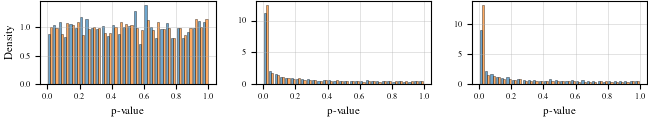

Results for crc in setting no_censor and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 10.36 / 24.57%
Proportion of p-values smaller than 0.05 = 4.86 / 17.25%
Proportion of p-values smaller than 0.01 = 1.07 / 8.75%
Results for crc in setting ic and models SA-TEDVAE-M1 / SA-TEDVAE-M2:
Proportion of p-values smaller than 0.1 = 29.86 / 18.71%
Proportion of p-values smaller than 0.05 = 21.57 / 12.11%
Proportion of p-values smaller than 0.01 = 12.14 / 4.50%


C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\266192653.py:311: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


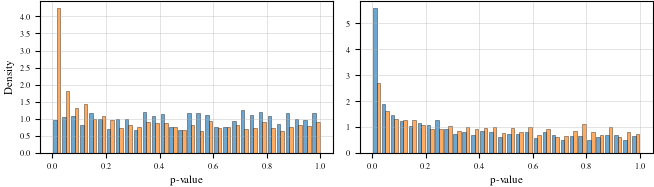

In [4]:
# ============================================================
# Cell 1: Compute p-values/stds + plot p-value histograms
# ============================================================

from matplotlib.patches import Patch

cases = ['ihdp', 'crc']

# Store everything needed by the second cell
case_results = {}

# Fixed colors for the histogram models
hist_colors = {
    'sa-tedvae-m1': plt.get_cmap('tab10')(0),
    'sa-tedvae-m2': plt.get_cmap('tab10')(1),
}

hist_labels = {
    'sa-tedvae-m1': 'SA-TEDVAE-CP',
    'sa-tedvae-m2': 'SA-TEDVAE-CT',
}


def save_hist_legend(save_path):
    legend_handles = [
        Patch(
            facecolor=hist_colors['sa-tedvae-m1'],
            edgecolor='black',
            alpha=0.65,
            label=hist_labels['sa-tedvae-m1']
        ),
        Patch(
            facecolor=hist_colors['sa-tedvae-m2'],
            edgecolor='black',
            alpha=0.65,
            label=hist_labels['sa-tedvae-m2']
        ),
    ]

    legend_width = plt.rcParams["figure.figsize"][0]

    fig_legend, ax_legend = plt.subplots(figsize=(legend_width/3.5, 0.2))
    ax_legend.axis("off")

    ax_legend.legend(
        handles=legend_handles,
        loc="center",
        ncol=2,
        frameon=True,
        bbox_to_anchor=(0, 0, 1, 1),
        mode="expand",
        borderaxespad=0,
        handlelength=1.5,
        columnspacing=1.0
    )

    fig_legend.savefig(
        save_path,
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig_legend)


for case in cases:

    if case == 'ihdp':
        save_path = os.path.join(
            os.path.dirname(os.path.abspath(os.getcwd())),
            'evaluation',
            'results_IHDP'
        )
        num_covars = 25

    elif case == 'crc':
        save_path = os.path.join(
            os.path.dirname(os.path.abspath(os.getcwd())),
            'evaluation',
            'results_CRC_censoring'
        )
        num_covars = 12

    else:
        raise RuntimeError('Case not recognized ' + str(case))

    results_path = os.path.join(save_path, 'results')
    plots_path = os.path.join(save_path, 'plots')

    with open(os.path.join(results_path, 'results.pkl'), 'rb') as f:
        results = pickle.load(f)

    settings = [key for key in results.keys()]
    models = [key for key in results[settings[0]].keys()]
    n_datasets = len(results[settings[0]][models[0]]['ate_error_test'])

    p_vals_dict = {}

    std_dict = {
        setting: {
            'scale_0': [],
            'scale_1': [],
            'concentration_0': [],
            'concentration_1': [],
            'prop_0': [],
            'prop_1': []
        }
        for setting in settings
    }

    for model_name in ['sa-tedvae-m1', 'sa-tedvae-m2']:
        p_vals_dict[model_name] = {}

        for setting in settings:
            p_vals_dict[model_name][setting] = []

            for i in range(n_datasets):

                if case == 'ihdp':
                    data = load_ihdp_data(i=i + 1, setting=setting)
                else:
                    data = load_crc_data(i=i, setting=setting)

                if model_name == 'sa-tedvae-m1':
                    c_0 = results[setting][model_name]['c_test'][i][0]
                    c_1 = results[setting][model_name]['c_test'][i][1]

                    std_dict[setting]['prop_0'].append(np.std(c_0))
                    std_dict[setting]['prop_1'].append(np.std(c_1))

                    vals_to_test = (c_0, c_1)

                else:
                    scale_0 = results[setting][model_name]['censor_scale_test'][i][0]
                    concentration_0 = results[setting][model_name]['censor_concentration_test'][i][0]

                    scale_1 = results[setting][model_name]['censor_scale_test'][i][1]
                    concentration_1 = results[setting][model_name]['censor_concentration_test'][i][1]

                    std_dict[setting]['scale_0'].append(np.std(scale_0))
                    std_dict[setting]['scale_1'].append(np.std(scale_1))

                    std_dict[setting]['concentration_0'].append(np.std(concentration_0))
                    std_dict[setting]['concentration_1'].append(np.std(concentration_1))

                    vals_to_test = (
                        scale_0,
                        scale_1,
                        concentration_0,
                        concentration_1
                    )

                # For each covariate, split above/below median and run Mann-Whitney U test
                p_vals = []

                for covar in range(len(data['data_types'])):
                    dtype = data['data_types'][covar]

                    if (dtype == 'continuous') or ('categorical' in dtype):
                        covar_data = data['X_test'][:, covar]
                        median = np.median(covar_data)

                        idx_1 = np.where(covar_data <= median)[0]
                        idx_2 = np.where(covar_data > median)[0]

                    elif dtype == 'binary':
                        covar_data = data['X_test'][:, covar]

                        idx_1 = np.where(covar_data <= 0.5)[0]
                        idx_2 = np.where(covar_data > 0.5)[0]

                    else:
                        raise ValueError(
                            "Unrecognized data type " + str(data['data_types'][covar])
                        )

                    n1, n2 = len(idx_1), len(idx_2)

                    if min(n1, n2) >= 20 and 0.5 < (n1 / n2) < 2.0:
                        for val in vals_to_test:
                            p_val = mannwhitneyu(val[idx_1], val[idx_2])[1]
                            p_vals.append(p_val)

                p_vals_dict[model_name][setting].append(p_vals)

            p_vals_dict[model_name][setting] = np.array(
                p_vals_dict[model_name][setting]
            ).squeeze()

    # Print numerical results
    for setting in settings:
        print(
            f'Results for {case} in setting {setting} '
            f'and models SA-TEDVAE-M1 / SA-TEDVAE-M2:'
        )

        m1_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.1)
            / p_vals_dict['sa-tedvae-m1'][setting].size
        )

        m2_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.1)
            / p_vals_dict['sa-tedvae-m2'][setting].size
        )

        print(f'Proportion of p-values smaller than 0.1 = {m1_vals:.2f} / {m2_vals:.2f}%')

        m1_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.05)
            / p_vals_dict['sa-tedvae-m1'][setting].size
        )

        m2_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.05)
            / p_vals_dict['sa-tedvae-m2'][setting].size
        )

        print(f'Proportion of p-values smaller than 0.05 = {m1_vals:.2f} / {m2_vals:.2f}%')

        m1_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m1'][setting] < 0.01)
            / p_vals_dict['sa-tedvae-m1'][setting].size
        )

        m2_vals = (
            100
            * np.sum(p_vals_dict['sa-tedvae-m2'][setting] < 0.01)
            / p_vals_dict['sa-tedvae-m2'][setting].size
        )

        print(f'Proportion of p-values smaller than 0.01 = {m1_vals:.2f} / {m2_vals:.2f}%')

    # Store everything needed by Cell 2
    case_results[case] = {
        'settings': settings,
        'plots_path': plots_path,
        'p_vals_dict': p_vals_dict,
        'std_dict': std_dict,
    }

    # --------------------------------------------------------
    # Plot and save separate legend for the p-value histogram
    # --------------------------------------------------------

    with plt.rc_context({
        **bundles.icml2024(
            column='full',
            nrows=1,
            ncols=len(settings),
            usetex=True
        )
    }):

        save_hist_legend(
            os.path.join(plots_path, f'censor_hist_{case}_legend.pdf')
        )

    # --------------------------------------------------------
    # Plot and save p-value histogram figure without legend
    # --------------------------------------------------------

    with plt.rc_context({
        **bundles.icml2024(
            column='full',
            nrows=1,
            ncols=len(settings),
            usetex=True
        )
    }):

        fig, axes = plt.subplots(
            1,
            len(settings),
            squeeze=False
        )

        axes = axes.ravel()

        for i, setting in enumerate(settings):
            ax = axes[i]

            ax.hist(
                [
                    p_vals_dict['sa-tedvae-m1'][setting].flatten(),
                    p_vals_dict['sa-tedvae-m2'][setting].flatten()
                ],
                bins=30,
                density=True,
                color=[
                    hist_colors['sa-tedvae-m1'],
                    hist_colors['sa-tedvae-m2']
                ],
                alpha=0.65,
                edgecolor='black',
                linewidth=0.4
            )

            ax.set_xlabel('p-value')
            if i==0:
                ax.set_ylabel('Density')
            ax.grid(True)

        fig.tight_layout()

        plt.rcParams.update(bundles.icml2024(usetex=False))

        fig.savefig(
            os.path.join(plots_path, f'censor_hist_{case}.pdf'),
            dpi=300,
            facecolor='white',
            bbox_inches='tight'
        )

        plt.show()
        plt.close(fig)

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\191999916.py:133: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


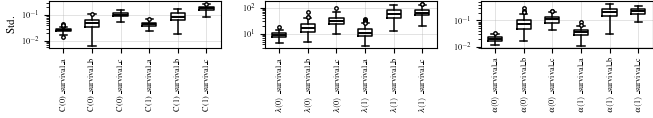

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\191999916.py:133: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


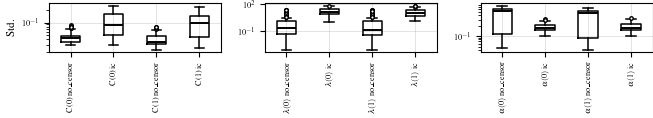

In [5]:
# ============================================================
# Cell 2: Plot parameter standard-deviation boxplots
# Requires Cell 1 to have been run first
# ============================================================

for case in cases:

    settings = case_results[case]['settings']
    plots_path = case_results[case]['plots_path']
    std_dict = case_results[case]['std_dict']

    with plt.rc_context({
        **bundles.icml2024(
            column='full',
            nrows=1,
            ncols=3,
            usetex=True
        )
    }):

        fig, axes = plt.subplots(1, 3)

        # ----------------------------------------------------
        # Censoring probability std, SA-TEDVAE-M1
        # ----------------------------------------------------

        ax = axes[0]

        props = (
            [std_dict[s]['prop_0'] for s in settings]
            + [std_dict[s]['prop_1'] for s in settings]
        )

        labels = (
            [f'C(0) {s}' for s in settings]
            + [f'C(1) {s}' for s in settings]
        )

        ax.boxplot(
            np.array(props).T,
            boxprops=dict(color='black', linewidth=1.1),
            whiskerprops=dict(color='black', linewidth=1.1),
            capprops=dict(color='black', linewidth=1.1),
            medianprops=dict(color='black', linewidth=1.4),
            flierprops=dict(
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=2.5,
                linestyle='none'
            )
        )
        ax.set_ylabel('Std.')
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=90)
        ax.set_yscale('log')
        ax.grid(True)

        # ----------------------------------------------------
        # Scale std, SA-TEDVAE-M2
        # ----------------------------------------------------

        ax = axes[1]

        scales = (
            [std_dict[s]['scale_0'] for s in settings]
            + [std_dict[s]['scale_1'] for s in settings]
        )

        labels = (
            [f'$\\lambda(0)$ {s}' for s in settings]
            + [f'$\\lambda(1)$ {s}' for s in settings]
        )

        ax.boxplot(
            np.array(scales).T,
            boxprops=dict(color='black', linewidth=1.1),
            whiskerprops=dict(color='black', linewidth=1.1),
            capprops=dict(color='black', linewidth=1.1),
            medianprops=dict(color='black', linewidth=1.4),
            flierprops=dict(
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=2.5,
                linestyle='none'
            )
        )

        # ax.set_ylabel('Standard deviation')
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=90)
        ax.set_yscale('log')
        ax.grid(True)

        # ----------------------------------------------------
        # Concentration std, SA-TEDVAE-M2
        # ----------------------------------------------------

        ax = axes[2]

        concs = (
            [std_dict[s]['concentration_0'] for s in settings]
            + [std_dict[s]['concentration_1'] for s in settings]
        )

        labels = (
            [f'$\\alpha(0)$ {s}' for s in settings]
            + [f'$\\alpha(1)$ {s}' for s in settings]
        )

        ax.boxplot(
            np.array(concs).T,
            boxprops=dict(color='black', linewidth=1.1),
            whiskerprops=dict(color='black', linewidth=1.1),
            capprops=dict(color='black', linewidth=1.1),
            medianprops=dict(color='black', linewidth=1.4),
            flierprops=dict(
                marker='o',
                markerfacecolor='white',
                markeredgecolor='black',
                markersize=2.5,
                linestyle='none'
            )
        )

        # ax.set_ylabel('Std.')
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=90)
        ax.set_yscale('log')
        ax.grid(True)

        fig.tight_layout()

        plt.rcParams.update(bundles.icml2024(usetex=False))

        fig.savefig(
            os.path.join(plots_path, f'censor_{case}_params.pdf'),
            dpi=300,
            facecolor='white',
            bbox_inches='tight'
        )

        plt.show()
        plt.close(fig)

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\1628987353.py:204: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


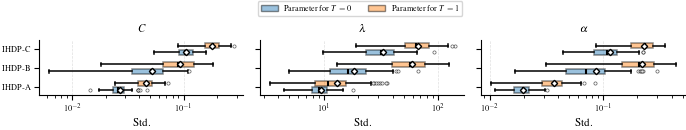

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\1628987353.py:204: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


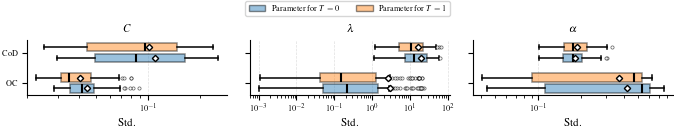

In [6]:
# ============================================================
# Cell 2: Plot parameter standard-deviation boxplots
# Redesigned as horizontal grouped boxplots
# ============================================================

from matplotlib.patches import Patch

treatment_colors = {
    0: plt.get_cmap("tab10")(0),
    1: plt.get_cmap("tab10")(1),
}


def clean_positive(values):
    values = np.asarray(values, dtype=float)
    return values[values > 0]


def draw_grouped_horizontal_boxplot(
    ax,
    values_0,
    values_1,
    settings,
    title,
    show_ylabels=False
):
    n_settings = len(settings)
    base_positions = np.arange(n_settings)

    offset = 0.18
    width = 0.28

    values_0 = [clean_positive(v) for v in values_0]
    values_1 = [clean_positive(v) for v in values_1]

    common_props = dict(
        vert=False,
        patch_artist=True,
        widths=width,
        showmeans=True,
        manage_ticks=False,
        boxprops=dict(
            linewidth=1.1,
            color="black"
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black"
        ),
        capprops=dict(
            linewidth=1.1,
            color="black"
        ),
        medianprops=dict(
            linewidth=1.5,
            color="black"
        ),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.2
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.5,
            markersize=2.3,
            alpha=0.65,
            linestyle="none"
        )
    )

    box_0 = ax.boxplot(
        values_0,
        positions=base_positions - offset,
        **common_props
    )

    box_1 = ax.boxplot(
        values_1,
        positions=base_positions + offset,
        **common_props
    )

    for patch in box_0["boxes"]:
        patch.set_facecolor(treatment_colors[0])
        patch.set_alpha(0.45)

    for patch in box_1["boxes"]:
        patch.set_facecolor(treatment_colors[1])
        patch.set_alpha(0.45)

    ax.set_title(title)
    ax.set_xlabel("Std.")
    ax.set_xscale("log")

    ax.set_yticks(base_positions)

    if show_ylabels:
        ax.set_yticklabels(settings)

        # ax.set_ylabel("Setting")
    else:
        ax.set_yticklabels([])

    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


for jj, case in enumerate(cases):

    settings = case_results[case]['settings']
    plots_path = case_results[case]['plots_path']
    std_dict = case_results[case]['std_dict']

    with plt.rc_context({
        **bundles.icml2024(
            column='full',
            nrows=1,
            ncols=3,
            usetex=True
        )
        }):

        fig, axes = plt.subplots(1, 3, sharey=True)

        # ----------------------------------------------------
        # Censoring probability std, SA-TEDVAE-M1
        # ----------------------------------------------------

        prop_0 = [std_dict[s]['prop_0'] for s in settings]
        prop_1 = [std_dict[s]['prop_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[0],
            values_0=prop_0,
            values_1=prop_1,
            settings=settings,
            title=r"$C$",
            show_ylabels=True
        )

        # ----------------------------------------------------
        # Scale std, SA-TEDVAE-M2
        # ----------------------------------------------------

        scale_0 = [std_dict[s]['scale_0'] for s in settings]
        scale_1 = [std_dict[s]['scale_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[1],
            values_0=scale_0,
            values_1=scale_1,
            settings=settings,
            title=r"$\lambda$",
            show_ylabels=False
        )

        # ----------------------------------------------------
        # Concentration std, SA-TEDVAE-M2
        # ----------------------------------------------------

        concentration_0 = [std_dict[s]['concentration_0'] for s in settings]
        concentration_1 = [std_dict[s]['concentration_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[2],
            values_0=concentration_0,
            values_1=concentration_1,
            settings=settings,
            title=r"$\alpha$",
            show_ylabels=False
        )

        legend_handles = [
            Patch(
                facecolor=treatment_colors[0],
                edgecolor="black",
                alpha=0.45,
                label=r"Parameter for $T=0$"
            ),
            Patch(
                facecolor=treatment_colors[1],
                edgecolor="black",
                alpha=0.45,
                label=r"Parameter for $T=1$"
            )
        ]

        fig.legend(
            handles=legend_handles,
            loc="upper center",
            ncol=2,
            frameon=True,
            bbox_to_anchor=(0.5, 1.03)
        )

        fig.tight_layout(rect=[0, 0, 1, 0.92])

        plt.rcParams.update(bundles.icml2024(usetex=False))

        if jj==0:
            axes[0].set_yticklabels(['IHDP-A', 'IHDP-B', 'IHDP-C'])
        elif jj==1:
            axes[0].set_yticklabels(['OC', 'CoD'])

        fig.savefig(
            os.path.join(plots_path, f'censor_{case}_params.pdf'),
            dpi=300,
            facecolor="white",
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\1101015851.py:207: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


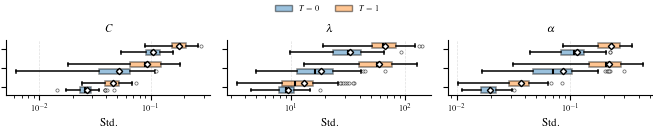

C:\Users\Alex\AppData\Local\Temp\ipykernel_29076\1101015851.py:207: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0, 1, 0.92])


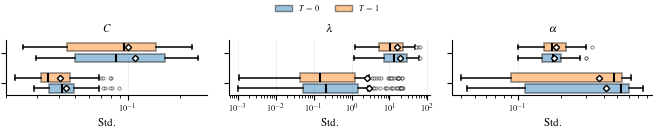

In [7]:
# ============================================================
# Cell 2: Plot parameter standard-deviation boxplots
# Redesigned as horizontal grouped boxplots
# ============================================================

from matplotlib.patches import Patch

treatment_colors = {
    0: plt.get_cmap("tab10")(0),
    1: plt.get_cmap("tab10")(1),
}


def clean_positive(values):
    values = np.asarray(values, dtype=float)
    return values[values > 0]


def draw_grouped_horizontal_boxplot(
    ax,
    values_0,
    values_1,
    setting_labels,
    title,
    show_ylabels=False
):
    n_settings = len(setting_labels)
    base_positions = np.arange(n_settings)

    offset = 0.18
    width = 0.28

    values_0 = [clean_positive(v) for v in values_0]
    values_1 = [clean_positive(v) for v in values_1]

    common_props = dict(
        vert=False,
        patch_artist=True,
        widths=width,
        showmeans=True,
        manage_ticks=False,
        boxprops=dict(
            linewidth=1.1,
            color="black"
        ),
        whiskerprops=dict(
            linewidth=1.1,
            color="black"
        ),
        capprops=dict(
            linewidth=1.1,
            color="black"
        ),
        medianprops=dict(
            linewidth=1.5,
            color="black"
        ),
        meanprops=dict(
            marker="D",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=3.2
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.5,
            markersize=2.3,
            alpha=0.65,
            linestyle="none"
        )
    )

    box_0 = ax.boxplot(
        values_0,
        positions=base_positions - offset,
        **common_props
    )

    box_1 = ax.boxplot(
        values_1,
        positions=base_positions + offset,
        **common_props
    )

    for patch in box_0["boxes"]:
        patch.set_facecolor(treatment_colors[0])
        patch.set_alpha(0.45)

    for patch in box_1["boxes"]:
        patch.set_facecolor(treatment_colors[1])
        patch.set_alpha(0.45)

    ax.set_title(title)
    ax.set_xlabel("Std.")
    ax.set_xscale("log")

    ax.set_yticks(base_positions)

    if show_ylabels:
        ax.set_yticklabels(setting_labels)
    else:
        ax.set_yticklabels([])

    ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.grid(False, axis="y")
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


for case in cases:

    settings = case_results[case]['settings']
    plots_path = case_results[case]['plots_path']
    std_dict = case_results[case]['std_dict']

    setting_labels = [
        f"{case.upper()}-{chr(ord('A') + i)}"
        for i in range(len(settings))
    ]

    with plt.rc_context({
        **bundles.icml2024(
            column='full',
            nrows=1,
            ncols=3,
            usetex=True
        )
    }):

        fig, axes = plt.subplots(1, 3, sharey=True)

        # ----------------------------------------------------
        # Censoring probability std, SA-TEDVAE-M1
        # ----------------------------------------------------

        prop_0 = [std_dict[s]['prop_0'] for s in settings]
        prop_1 = [std_dict[s]['prop_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[0],
            values_0=prop_0,
            values_1=prop_1,
            setting_labels=setting_labels,
            title=r"$C$",
            show_ylabels=True
        )

        # ----------------------------------------------------
        # Scale std, SA-TEDVAE-M2
        # ----------------------------------------------------

        scale_0 = [std_dict[s]['scale_0'] for s in settings]
        scale_1 = [std_dict[s]['scale_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[1],
            values_0=scale_0,
            values_1=scale_1,
            setting_labels=setting_labels,
            title=r"$\lambda$",
            show_ylabels=False
        )

        # ----------------------------------------------------
        # Concentration std, SA-TEDVAE-M2
        # ----------------------------------------------------

        concentration_0 = [std_dict[s]['concentration_0'] for s in settings]
        concentration_1 = [std_dict[s]['concentration_1'] for s in settings]

        draw_grouped_horizontal_boxplot(
            ax=axes[2],
            values_0=concentration_0,
            values_1=concentration_1,
            setting_labels=setting_labels,
            title=r"$\alpha$",
            show_ylabels=False
        )

        legend_handles = [
            Patch(
                facecolor=treatment_colors[0],
                edgecolor="black",
                alpha=0.45,
                label=r"$T=0$"
            ),
            Patch(
                facecolor=treatment_colors[1],
                edgecolor="black",
                alpha=0.45,
                label=r"$T=1$"
            )
        ]

        fig.legend(
            handles=legend_handles,
            loc="upper center",
            ncol=2,
            frameon=False,
            bbox_to_anchor=(0.5, 1.03)
        )

        fig.tight_layout(rect=[0, 0, 1, 0.92])

        plt.rcParams.update(bundles.icml2024(usetex=False))

        fig.savefig(
            os.path.join(plots_path, f'censor_{case}_params.pdf'),
            dpi=300,
            facecolor="white",
            bbox_inches="tight"
        )

        plt.show()
        plt.close(fig)